In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/14 Days of ML/Day 9  Clustering (K-Means, DBSCAN)/Mall_Customers.csv")
print(" Mall Customers Dataset Loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

 Mall Customers Dataset Loaded!
Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
m

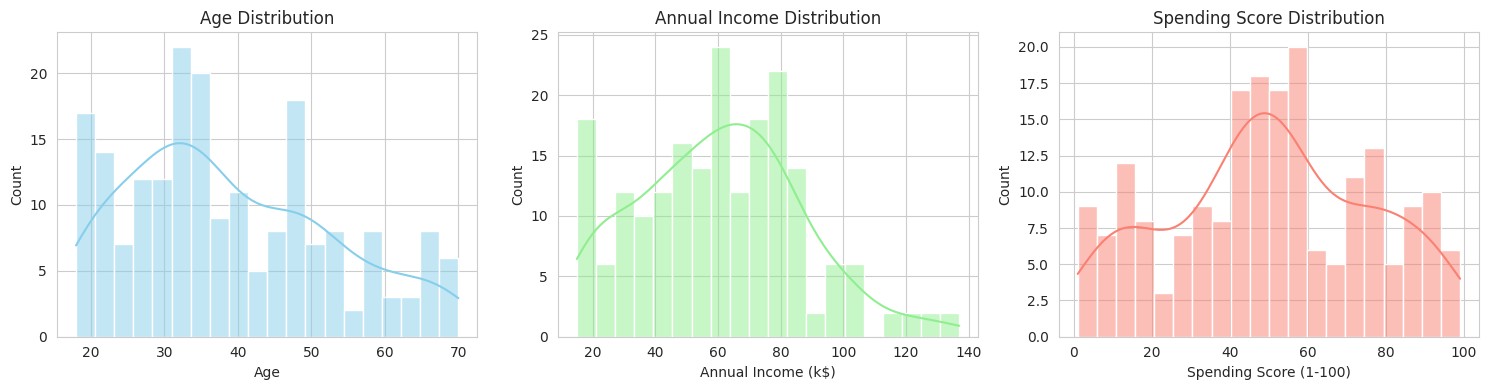

Distributions visualized!

Age range: 18 - 70 years
Income range: 15 - 137 k$
Spending Score range: 1 - 99


In [2]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Annual Income distribution
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

print("Distributions visualized!")
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Income range: {df['Annual Income (k$)'].min()} - {df['Annual Income (k$)'].max()} k$")
print(f"Spending Score range: {df['Spending Score (1-100)'].min()} - {df['Spending Score (1-100)'].max()}")

In [3]:
from sklearn.preprocessing import StandardScaler

# Select relevant features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Selected Features:")
print(X.head())

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully!")
print(f"Shape: {X_scaled.shape}")
print(f"\nFirst 5 scaled values:")
print(X_scaled[:5])

Selected Features:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Features scaled successfully!
Shape: (200, 2)

First 5 scaled values:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


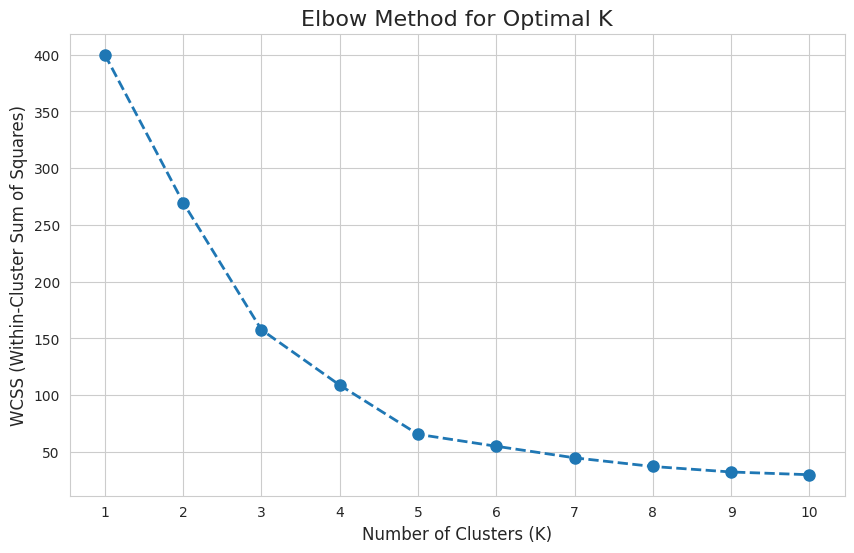

WCSS for each K:
K=1: 400.00
K=2: 269.69
K=3: 157.70
K=4: 108.92
K=5: 65.57
K=6: 55.06
K=7: 44.86
K=8: 37.23
K=9: 32.39
K=10: 29.98


In [4]:
from sklearn.cluster import KMeans

# Calculation WCSS (Within-Cluster Sum of Squares) for different K values
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Ploti elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Show WCSS values
print("WCSS for each K:")
for k, w in zip(k_range, wcss):
    print(f"K={k}: {w:.2f}")

In [5]:
from sklearn.cluster import KMeans

# Based on elbow plot, optimal K = 5
optimal_k = 5

# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

print(f"K-Means applied with K={optimal_k}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Show cluster centers (in original scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster Centers (Income, Spending Score):")
for i, center in enumerate(centers):
    print(f"Cluster {i}: Income=${center[0]:.1f}k, Spending={center[1]:.1f}")

K-Means applied with K=5

Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (Income, Spending Score):
Cluster 0: Income=$55.3k, Spending=49.5
Cluster 1: Income=$86.5k, Spending=82.1
Cluster 2: Income=$25.7k, Spending=79.4
Cluster 3: Income=$88.2k, Spending=17.1
Cluster 4: Income=$26.3k, Spending=20.9


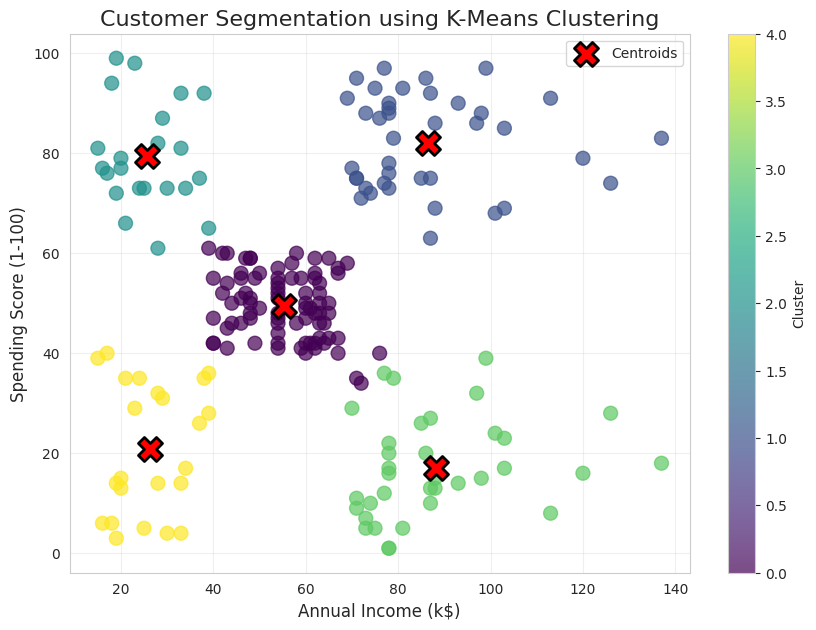

In [6]:
# Visualize clusters
plt.figure(figsize=(10, 7))

# Scatter plot with colors
scatter = plt.scatter(df['Annual Income (k$)'],
                      df['Spending Score (1-100)'],
                      c=df['Cluster'],
                      cmap='viridis',
                      s=100,
                      alpha=0.7)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='red', marker='X', s=300,
            label='Centroids', edgecolors='black', linewidth=2)

plt.title('Customer Segmentation using K-Means Clustering', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for K={optimal_k}: {sil_score:.4f}")

# Interpretation
if sil_score > 0.5:
    print("   Excellent! Clusters are well-separated and distinct.")
elif sil_score > 0.3:
    print("   Good! Clusters are reasonably well-separated.")
elif sil_score > 0.2:
    print("   Fair. Some overlap between clusters.")
else:
    print("   Poor. Clusters may not be well-defined.")

Silhouette Score for K=5: 0.5547
   Excellent! Clusters are well-separated and distinct.


===== DBSCAN Clustering =====
Number of clusters: 2
Number of outliers: 8

Cluster distribution:
DBSCAN_Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64


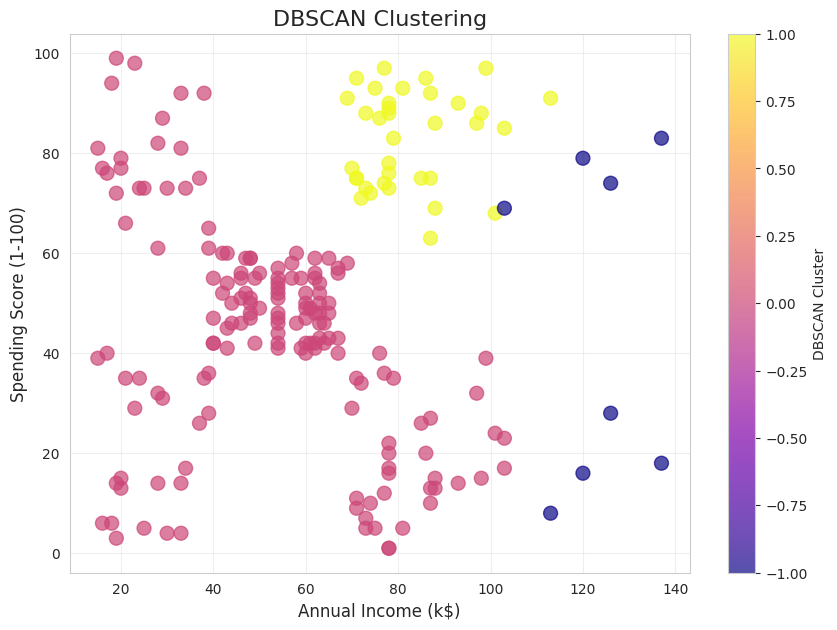

In [8]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN labels to dataframe
df['DBSCAN_Cluster'] = dbscan_labels

print("===== DBSCAN Clustering =====")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of outliers: {list(dbscan_labels).count(-1)}")
print("\nCluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# Visualize DBSCAN
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual Income (k$)'],
                      df['Spending Score (1-100)'],
                      c=dbscan_labels,
                      cmap='plasma',
                      s=100,
                      alpha=0.7)
plt.title('DBSCAN Clustering', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.colorbar(scatter, label='DBSCAN Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Compare K-Means and DBSCAN
print("=" * 60)
print("K-MEANS vs DBSCAN COMPARISON")
print("=" * 60)

print("\n K-MEANS:")
print(f"   - Clusters: 5")
print(f"   - Silhouette Score: 0.5547")
print(f"   - All points assigned to clusters")
print("   - Good for spherical clusters")

print("\n DBSCAN:")
print(f"   - Clusters: 2")
print(f"   - Outliers: 8 points (4%)")
print(f"   - Can find arbitrary shapes")
print("   - Good for identifying outliers")

print("\n Key Differences:")
print("   - K-Means: Every point belongs to a cluster")
print("   - DBSCAN: Can label points as outliers/noise")
print("   - K-Means: Better for this dataset (higher Silhouette Score)")
print("   - DBSCAN: Better when you have outliers")

# Silhouette Score for DBSCAN (excluding outliers)
dbscan_labels_filtered = dbscan_labels[dbscan_labels != -1]
X_scaled_filtered = X_scaled[dbscan_labels != -1]

try:
    dbscan_sil = silhouette_score(X_scaled_filtered, dbscan_labels_filtered)
    print(f"\n DBSCAN Silhouette Score: {dbscan_sil:.4f} (excluding outliers)")
except:
    print("\n DBSCAN: Could not compute silhouette score")

K-MEANS vs DBSCAN COMPARISON

 K-MEANS:
   - Clusters: 5
   - Silhouette Score: 0.5547
   - All points assigned to clusters
   - Good for spherical clusters

 DBSCAN:
   - Clusters: 2
   - Outliers: 8 points (4%)
   - Can find arbitrary shapes
   - Good for identifying outliers

 Key Differences:
   - K-Means: Every point belongs to a cluster
   - DBSCAN: Can label points as outliers/noise
   - K-Means: Better for this dataset (higher Silhouette Score)
   - DBSCAN: Better when you have outliers

 DBSCAN Silhouette Score: 0.3876 (excluding outliers)


In [11]:
# Profile each cluster
print("=" * 60)
print(" CUSTOMER SEGMENTATION - CLUSTER PROFILES")
print("=" * 60)

# Get cluster centers in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Profile descriptions
profiles = {
    0: " Standard Customers - Average income, Average spending",
    1: " VIP Customers - High income, High spending (Best segment!)",
    2: " Careful Spenders - Low income, High spending (Living beyond means?)",
    3: " Frugal Customers - High income, Low spending",
    4: " Low Income/Low Spenders - Low income, Low spending"
}

for i in range(5):
    income = centers[i][0]
    spending = centers[i][1]
    print(f"\n Cluster {i}: {profiles[i]}")
    print(f"   - Average Income: ${income:.1f}k")
    print(f"   - Average Spending Score: {spending:.1f}")
    print(f"   - Number of Customers: {sum(df['Cluster'] == i)}")

# Business recommendations
print("\n" + "=" * 60)
print(" MARKETING RECOMMENDATIONS")
print("=" * 60)

print("\n VIP Customers (High Income, High Spenders):")
print("   → Loyalty programs, Premium offers, Exclusive deals")

print("\n Frugal Customers (High Income, Low Spenders):")
print("   → Targeted marketing, Show value, Upsell opportunities")

print("\n Careful Spenders (Low Income, High Spenders):")
print("   → Budget-friendly offers, Discounts, Financing options")

print("\n Low Income/Low Spenders:")
print("   → Basic products, Entry-level pricing, Gradual upgrades")

print("\n Standard Customers:")
print("   → Balanced marketing, General offers, Build loyalty")

 CUSTOMER SEGMENTATION - CLUSTER PROFILES

 Cluster 0:  Standard Customers - Average income, Average spending
   - Average Income: $55.3k
   - Average Spending Score: 49.5
   - Number of Customers: 81

 Cluster 1:  VIP Customers - High income, High spending (Best segment!)
   - Average Income: $86.5k
   - Average Spending Score: 82.1
   - Number of Customers: 39

 Cluster 2:  Careful Spenders - Low income, High spending (Living beyond means?)
   - Average Income: $25.7k
   - Average Spending Score: 79.4
   - Number of Customers: 22

 Cluster 3:  Frugal Customers - High income, Low spending
   - Average Income: $88.2k
   - Average Spending Score: 17.1
   - Number of Customers: 35

 Cluster 4:  Low Income/Low Spenders - Low income, Low spending
   - Average Income: $26.3k
   - Average Spending Score: 20.9
   - Number of Customers: 23

 MARKETING RECOMMENDATIONS

 VIP Customers (High Income, High Spenders):
   → Loyalty programs, Premium offers, Exclusive deals

 Frugal Customers (High In

In [12]:
import joblib
import os

# Save K-Means model and scaler
folder_path = '/content/drive/MyDrive/14 Days of ML/Day 9  Clustering (K-Means, DBSCAN)/'
os.makedirs(folder_path, exist_ok=True)

# Save K-Means model
joblib.dump(kmeans, os.path.join(folder_path, 'kmeans_model.pkl'))

# Save scaler
joblib.dump(scaler, os.path.join(folder_path, 'scaler.pkl'))

# Save cluster profiles as text
with open(os.path.join(folder_path, 'cluster_profiles.txt'), 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("CUSTOMER SEGMENTATION - CLUSTER PROFILES\n")
    f.write("=" * 60 + "\n\n")

    profiles = {
        0: "Standard Customers - Average income, Average spending",
        1: "VIP Customers - High income, High spending (Best segment!)",
        2: "Careful Spenders - Low income, High spending (Living beyond means?)",
        3: "Frugal Customers - High income, Low spending",
        4: "Low Income/Low Spenders - Low income, Low spending"
    }

    centers = scaler.inverse_transform(kmeans.cluster_centers_)

    for i in range(5):
        income = centers[i][0]
        spending = centers[i][1]
        count = sum(df['Cluster'] == i)

        f.write(f"Cluster {i}: {profiles[i]}\n")
        f.write(f"   Average Income: ${income:.1f}k\n")
        f.write(f"   Average Spending Score: {spending:.1f}\n")
        f.write(f"   Number of Customers: {count}\n\n")

print("All files saved successfully!")
print(f"Location: {folder_path}")
print("\nFiles saved:")
print("- kmeans_model.pkl")
print("- scaler.pkl")
print("- cluster_profiles.txt")

All files saved successfully!
Location: /content/drive/MyDrive/14 Days of ML/Day 9  Clustering (K-Means, DBSCAN)/

Files saved:
- kmeans_model.pkl
- scaler.pkl
- cluster_profiles.txt
